<a href="https://colab.research.google.com/github/rajeshwarishirsat028-ship-it/ML_Practical_Lab/blob/main/mlt_practicle_no3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Logistic regression**

step1: Data collection

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [4]:
titanic_data = pd.read_csv('/titanic_data.csv')

In [5]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print(str(len(titanic_data.index))) # total no of passengers in original data

891


**step2: Analyzing the data**

kowing the data !!!plotting graphs!!!EDA

<Axes: xlabel='Survived', ylabel='count'>

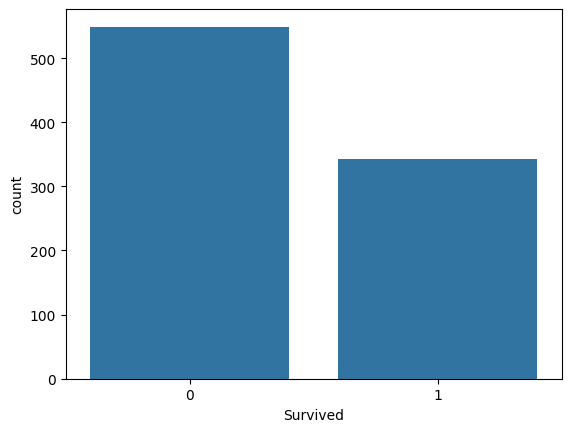

In [7]:
#knowing how many people survived and died
sns.countplot(x='Survived', data=titanic_data)

<Axes: xlabel='Survived', ylabel='count'>

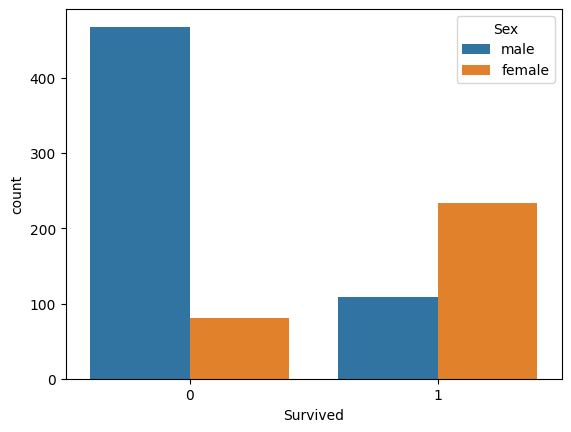

In [8]:
#knowing howmany male survided and how many females survived
sns.countplot(x='Survived', hue='Sex', data=titanic_data)

<Axes: xlabel='Survived', ylabel='count'>

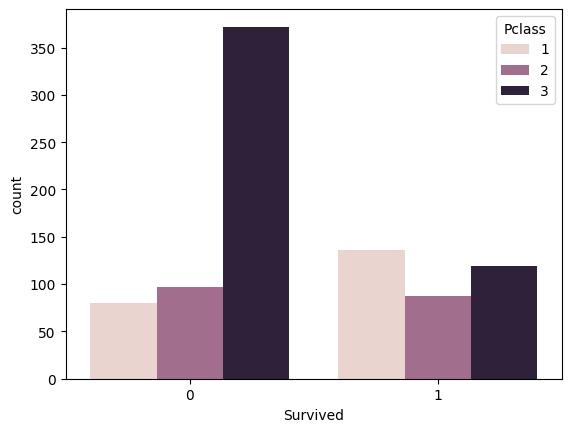

In [9]:
#Knowing which class people survived the most
sns.countplot(x='Survived', hue='Pclass', data=titanic_data)

<Axes: ylabel='Frequency'>

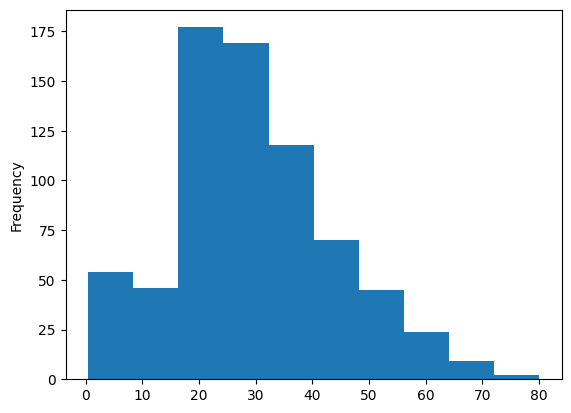

In [10]:
#Age distribution
titanic_data['Age'].plot.hist()

<Axes: ylabel='Frequency'>

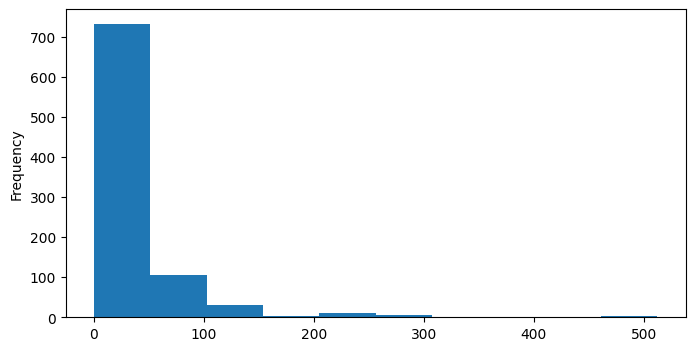

In [11]:
#fare- the amount of money a passenger paid for their tickit
titanic_data['Fare'].plot.hist(figsize=(8,4))

Exploratory data Analysis

In [12]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Step3:Data processing**

In [13]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
#imputation
titanic_data.drop('Cabin', axis=1, inplace=True)

In [15]:
titanic_data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


In [17]:
titanic_data.dropna(inplace=True)

In [18]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [19]:
titanic_data.head(5)
# we will first convert categorical variables into dummy variabls and then use them as logistic reg only takes 2 inputs

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Encoding

using logistic regression we will predict how many people survived and how many died in titanic ship.here 1 survived and 0 died

In [20]:
pd.get_dummies(titanic_data['Sex']).astype(int)

,female,male
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1
...,...,...
885,1,0
886,0,1
887,1,0
889,0,1


In [21]:
S = pd.get_dummies(titanic_data['Sex'],drop_first=True).astype(int)
S.head(4)

,male
0,1
1,0
2,0
3,0


In [22]:
#conversion of Embarked column from one form to another
#Q= Quinstown, S=southam , C= chambor
E = pd.get_dummies(titanic_data['Embarked'],drop_first=True).astype(int).astype(int)
E.head(4)

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
